# ⚖️ Regulus — AI Governance Standards Lookup

**Describe an AI issue or system in plain language; Regulus returns the regulatory provisions that apply — across frameworks, each with a source citation, cited cross-framework references, and an optional grounded interpretation.**

Regulus is, in one line, **RAG + a knowledge network**: retrieval over *real* regulatory text, enriched by a *cited* cross-framework graph, optionally interpreted by an LLM. It is built for AI governance and model-risk work, where the question is rarely *"what text is similar?"* but *"**which requirement applies, how does it map across frameworks, and can you show me the source?**"*

It is built on the [Geometric Knowledge Network (GKN)](https://github.com/minw0607/geometric_knowledge_network).

### This notebook, step by step
1. **Setup** — imports.
2. **Configure** — choose the standards, the retriever, and describe the AI system under review.
3. **Launch** — build the system (corpus + knowledge graph + interpreter) and show basic info.
4. **Scenarios** — realistic observations/questions to test.
5. **Retrieve & answer** — applicable provisions, then a grounded, cited interpretation.
6. **Visualize** — the regulatory neighborhood of the issue.

> **Guardrail:** every provision is a real, cited unit of an official framework; cross-framework crosswalks are **curated and cited, never invented**; and the LLM **interprets — it does not author regulation**.

## 1. Setup

In [5]:
# Auto-reload edited modules; no kernel restart needed after code changes.
try:
    _ip = get_ipython(); _ip.run_line_magic('load_ext', 'autoreload'); _ip.run_line_magic('autoreload', '2')
except Exception:
    pass

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))   # make `regulus` importable

from regulus import demo
demo.ensure_gkn()   # use installed GKN, or the local sibling checkout

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Configure the system

Set your choices below.

- **`STANDARDS`** — which frameworks to load (comment any out).
- **`RETRIEVER`** — `'auto'` (recommended) uses **embeddings** when your Azure/OpenAI keys are available (reused automatically from the GKN `.env`) and falls back to TF-IDF otherwise; force `'embedding'` or `'tfidf'`.
- **`TARGET_SYSTEM`** — a description of the AI system under review; the interpreter tailors its answer to it.

*Risk categories* are the seven NIST trustworthiness characteristics (valid & reliable, safe, secure & resilient, accountable & transparent, explainable, privacy-enhanced, fair) — applied automatically; to customize, edit `risk.py`.

*Retrieval quality note:* provisions are indexed as **provision-scoped units** (each with a framework/title header), not arbitrary character windows — this is what makes retrieval land on the right article. Section 3 measures it.

In [6]:
STANDARDS = [
    'eu_ai_act',      # EU AI Act — 113 articles
    'nist_ai_rmf',    # NIST AI RMF 1.0 — 72 subcategories
    'nist_ai_600_1',  # NIST AI 600-1 (GenAI Profile) — 49 action groups
    'oecd_ai',        # OECD AI Principles — 10
    'iso_42001',      # ISO/IEC 42001 — clause structure (reference)
]

# 'auto' uses embeddings when Azure/OpenAI keys are available (reused from GKN),
# else TF-IDF. Force with 'embedding' or 'tfidf'.
RETRIEVER = 'embedding'

TARGET_SYSTEM = (
    'A generative-AI customer-service assistant for a retail bank. It answers customer '
    'questions about mortgages, savings, and credit cards by retrieving from internal '
    'product documentation, and is live to the public.'
)

## 3. Launch the system

`demo.launch()` loads the chosen standards into citable provisions, builds the cited cross-framework knowledge network, and wires up the interpreter (it reuses your GKN Azure/OpenAI credentials automatically).

`overview()` is the **app card**: what Regulus is, the retrieval and generation models in use, the regulatory data store it covers, the knowledge-network structure, and its input/output contract — including the reproducibility guarantee.

In [7]:
reg = demo.launch(standards=STANDARDS, retriever=RETRIEVER, target_system=TARGET_SYSTEM)
reg.overview()

[DONE] EU AI Act: 113 provisions.
[INFO] NIST AI RMF 1.0: live parse unavailable (pypdf is required to parse the NIST AI RMF PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI RMF 1.0: 72 provisions (snapshot).
[INFO] NIST AI 600-1 (GenAI Profile): live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] NIST AI 600-1 (GenAI Profile): 49 provisions (snapshot).
[INFO] OECD AI Principles: live parse unavailable (pypdf is required to parse this PDF (pip install pypdf).); using committed snapshot.
[DONE] OECD AI Principles: 10 provisions (snapshot).
[DONE] ISO/IEC 42001:2023: 16 provisions (reference snapshot).
[DONE] Loaded 260 provisions from 5 framework(s).
[INFO] faiss not installed; using NumPy exact-search fallback for the embedding index.
[INFO] Embedding mode in effect: small (model: text-embedding-3-small)
[INFO] Loading cached vector store from /Users/minwu/Documents/GenAI/geometric_knowledge_network/chec

## Regulus — AI-governance standards lookup

**What it is.** Domain-specialized GraphRAG for AI governance. You describe an AI
system and a scenario; Regulus retrieves the applicable provisions across multiple
frameworks, links them through a **cited cross-framework knowledge network**, and
(optionally) has an LLM interpret them into a grounded, cited assessment.

**Models**
- *Retrieval / embeddings:* `text-embedding-3-small` (dense) over provision-scoped units.
- *Generation (interpretation):* `gpt-5-4-20260305-gs` at temperature 0.

**Regulatory data store (260 provisions across 5 frameworks)**
  - EU AI Act — 113 provisions
  - ISO/IEC 42001:2023 — 16 provisions
  - NIST AI 600-1 (GenAI Profile) — 49 provisions
  - NIST AI RMF 1.0 — 72 provisions
  - OECD AI Principles — 10 provisions

**Knowledge network (KN) structure**
- Nodes: `Framework` → `Provision` → `RiskCategory`.
- Edges: `CONTAINS` (framework→provision), `ADDRESSES` (provision→risk),
  `CROSSWALK` (provision↔provision across frameworks — **curated & cited, never
  LLM-invented**).
- Size: 260 provisions · 67 crosswalk edges ·
  7 risk categories.

**Input** — a plain-language scenario/observation (e.g. *"our credit model was
deployed without testing for demographic bias"*), plus an optional description of
the system under review.

**Output** — a structured assessment: (1) the **risks**, (2) the **applicable
provisions** (primary + cited related provisions in other frameworks), and
(3) an **interpretation with recommended mitigants**, each grounded in a cited
provision.

**Reproducibility** — the risks and provisions are computed by code from a single
retrieval pass over a fixed data store, so the same scenario yields the **same
core** every run. Only the LLM's wording (section 3) may vary; it is labeled and
runs at temperature 0.


'## Regulus — AI-governance standards lookup\n\n**What it is.** Domain-specialized GraphRAG for AI governance. You describe an AI\nsystem and a scenario; Regulus retrieves the applicable provisions across multiple\nframeworks, links them through a **cited cross-framework knowledge network**, and\n(optionally) has an LLM interpret them into a grounded, cited assessment.\n\n**Models**\n- *Retrieval / embeddings:* `text-embedding-3-small` (dense) over provision-scoped units.\n- *Generation (interpretation):* `gpt-5-4-20260305-gs` at temperature 0.\n\n**Regulatory data store (260 provisions across 5 frameworks)**\n  - EU AI Act — 113 provisions\n  - ISO/IEC 42001:2023 — 16 provisions\n  - NIST AI 600-1 (GenAI Profile) — 49 provisions\n  - NIST AI RMF 1.0 — 72 provisions\n  - OECD AI Principles — 10 provisions\n\n**Knowledge network (KN) structure**\n- Nodes: `Framework` → `Provision` → `RiskCategory`.\n- Edges: `CONTAINS` (framework→provision), `ADDRESSES` (provision→risk),\n  `CROSSWALK` 

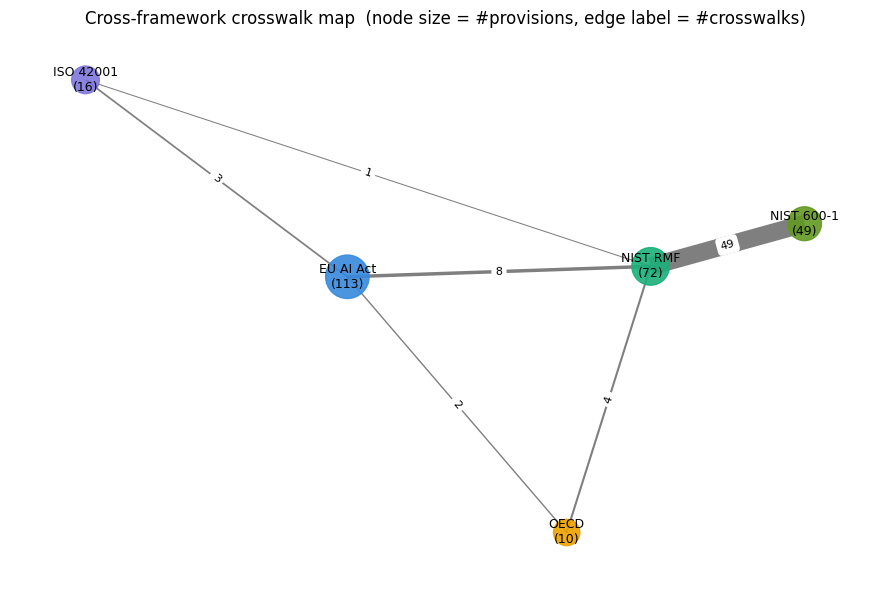

In [8]:
# The knowledge network at a glance: frameworks linked by the number of cited crosswalks.
_ = reg.framework_map()   # needs matplotlib

### Retrieval quality (does it find the right provision?)

A small labelled `issue → expected-provisions` set measures the data store — `hit` (any expected provision retrieved), `recall@k`, and `MRR`. This is how we tell whether a change to chunking or embeddings actually helps, rather than guessing. (Extend `regulus/eval.py` as coverage grows.)

In [9]:
# Retrieval quality on a small labelled eval set (hit-rate / recall@k / MRR).
demo.retrieval_report(reg, top_k=5)

,issue,hit,recall@k,mrr,top-1
0,Real-time facial recognition in public spaces ...,1.0,1.000,1.000,"EU AI Act, Article 5 — Prohibited AI practices"
1,Our credit model was deployed without testing ...,1.0,1.000,0.250,"NIST AI 600-1 (GenAI Profile), MS-2.11 — MEASU..."
2,No post-deployment monitoring of a high-risk A...,1.0,0.500,1.000,"EU AI Act, Article 72 — Post-market monitoring..."
3,Users are not told they are interacting with a...,1.0,1.000,1.000,"EU AI Act, Article 50 — Transparency obligatio..."
4,No human oversight of the model's automated de...,1.0,1.000,1.000,"EU AI Act, Article 14 — Human oversight"
5,The high-risk system was not validated for acc...,1.0,1.000,1.000,"EU AI Act, Article 15 — Accuracy, robustness a..."
6,No logging or records of the AI system's opera...,1.0,1.000,1.000,"EU AI Act, Article 12 — Record-keeping"
7,There is no risk management system for our hig...,1.0,1.000,1.000,"EU AI Act, Article 9 — Risk management system"
8,We provide no instructions for use or transpar...,1.0,1.000,1.000,"EU AI Act, Article 13 — Transparency and provi..."
9,No fundamental rights impact assessment was pe...,1.0,1.000,1.000,"EU AI Act, Article 27 — Fundamental rights imp..."


## 4. Test scenarios

Realistic, multi-issue observations. Pick one (or write your own) to run through the system.

In [10]:
# A categorized set of hypothetical scenarios (one per governance theme) lives in
# the module, so it's reusable and testable. Pick one to walk through.
from regulus import demo

for name in demo.SCENARIOS:
    print("\u2022", name)

scenario = demo.SCENARIOS['GenAI \u2014 hallucination & provenance']
print("\n" + scenario)

We launched a generative-AI assistant on our retail bank website that answers customer questions about mortgages, savings, and credit cards using retrieval over internal product documentation. In testing it occasionally states incorrect interest rates and invents promotional terms that do not exist, and it keeps no record of which documents it used for a given answer. It is live to the public and customers are not told they are talking to an AI.


## 5. Assess a scenario

`reg.assess(scenario)` produces the full, **reproducible** assessment, now organized as tables:

1. **Risks, standards & controls** \u2014 each risk, the provisions (standards) that govern it, and a suggested control/mitigant (a curated, deterministic control library \u2014 *pre-built rules*, not LLM output).
2. **Priority (graph leverage)** \u2014 which provision to address *first*. This is the knowledge-network insight (see \u00a76).
3. **Cross-framework reach** \u2014 provisions the graph surfaces by following crosswalks, that similarity retrieval alone missed.
4. **Interpretation & recommended mitigants** \u2014 the LLM narrates *why* and adds scenario-specific mitigants, each grounded in a cited provision.

Pass `export=True` to save the report to `artifacts/assessments/` as Markdown + JSON + CSV (deterministic core \u2192 byte-identical across runs; only \u00a74's wording can vary).

In [11]:
# Full assessment (rendered) + saved to artifacts/assessments/
assessment = reg.assess(scenario, export=True)

,provision,score,risks addressed,cross-framework references (cited)
0,"NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE...",0.502,"Explainable and interpretable, Fair — with har...","NIST AI RMF 1.0, MANAGE 3.2 — Manage function"
1,"NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASUR...",0.501,"Explainable and interpretable, Fair — with har...","NIST AI RMF 1.0, MEASURE 2.9 — Measure function"
2,"NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASUR...",0.497,"Safe, Secure and resilient, Valid and reliable","NIST AI RMF 1.0, MEASURE 2.5 — Measure function"
3,"NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE...",0.489,"Accountable and transparent, Secure and resili...","NIST AI RMF 1.0, MANAGE 4.1 — Manage function"
4,"NIST AI 600-1 (GenAI Profile), MG-4.2 — MANAGE...",0.485,"Fair — with harmful bias managed, Valid and re...","NIST AI RMF 1.0, MANAGE 4.2 — Manage function"
5,"NIST AI 600-1 (GenAI Profile), MS-2.10 — MEASU...",0.478,Fair — with harmful bias managed,"NIST AI RMF 1.0, MEASURE 2.10 — Measure function"


In [12]:
# The same core as tidy DataFrames (nice for filtering / exporting elsewhere):
assessment.risk_table()

## Regulus assessment
**System under review:** A generative-AI customer-service assistant for a retail bank. It answers customer questions about mortgages, savings, and credit cards by retrieving from internal product documentation, and is live to the public.
**Scenario:** We launched a generative-AI assistant on our retail bank website that answers customer questions about mortgages, savings, and credit cards using retrieval over internal product documentation. In testing it occasionally states incorrect interest rates and invents promotional terms that do not exist, and it keeps no record of which documents it used for a given answer. It is live to the public and customers are not told they are talking to an AI.

### 1. Risks in this scenario
- **Fair — with harmful bias managed** — governed by: NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions, NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions, NIST AI 600-1 (GenAI Profile), MG-4.2 — MANAGE 4.2 — generative-AI suggested actions
- **Valid and reliable** — governed by: NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions, NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions, NIST AI 600-1 (GenAI Profile), MG-4.2 — MANAGE 4.2 — generative-AI suggested actions
- **Explainable and interpretable** — governed by: NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions, NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions
- **Privacy-enhanced** — governed by: NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions, NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions
- **Secure and resilient** — governed by: NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions, NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions
- **Accountable and transparent** — governed by: NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions
- **Safe** — governed by: NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions

### 2. Applicable provisions
1. **NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions** (NIST AI 600-1 (GenAI Profile)) — relevance 0.502  
  _risks:_ Explainable and interpretable, Fair — with harmful bias managed, Privacy-enhanced
2. **NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions** (NIST AI 600-1 (GenAI Profile)) — relevance 0.501  
  _risks:_ Explainable and interpretable, Fair — with harmful bias managed, Privacy-enhanced
3. **NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions** (NIST AI 600-1 (GenAI Profile)) — relevance 0.497  
  _risks:_ Safe, Secure and resilient, Valid and reliable
4. **NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions** (NIST AI 600-1 (GenAI Profile)) — relevance 0.489  
  _risks:_ Accountable and transparent, Secure and resilient, Valid and reliable
5. **NIST AI 600-1 (GenAI Profile), MG-4.2 — MANAGE 4.2 — generative-AI suggested actions** (NIST AI 600-1 (GenAI Profile)) — relevance 0.485  
  _risks:_ Fair — with harmful bias managed, Valid and reliable

**Related cross-framework provisions (cited crosswalks):**
- **NIST AI RMF 1.0, MANAGE 3.2 — Manage function** (NIST AI RMF 1.0) — _supports_ of NIST AI 600-1 (GenAI Profile), MG-3.2 — MANAGE 3.2 — generative-AI suggested actions [source: NIST AI 600-1 keys its suggested actions to AI RMF subcategories (authoritative structural mapping).]
- **NIST AI RMF 1.0, MEASURE 2.9 — Measure function** (NIST AI RMF 1.0) — _supports_ of NIST AI 600-1 (GenAI Profile), MS-2.9 — MEASURE 2.9 — generative-AI suggested actions [source: NIST AI 600-1 keys its suggested actions to AI RMF subcategories (authoritative structural mapping).]
- **NIST AI RMF 1.0, MEASURE 2.5 — Measure function** (NIST AI RMF 1.0) — _supports_ of NIST AI 600-1 (GenAI Profile), MS-2.5 — MEASURE 2.5 — generative-AI suggested actions [source: NIST AI 600-1 keys its suggested actions to AI RMF subcategories (authoritative structural mapping).]
- **NIST AI RMF 1.0, MANAGE 4.1 — Manage function** (NIST AI RMF 1.0) — _supports_ of NIST AI 600-1 (GenAI Profile), MG-4.1 — MANAGE 4.1 — generative-AI suggested actions [source: NIST AI 600-1 keys its suggested actions to AI RMF subcategories (authoritative structural mapping).]
- **NIST AI RMF 1.0, MANAGE 4.2 — Manage function** (NIST AI RMF 1.0) — _supports_ of NIST AI 600-1 (GenAI Profile), MG-4.2 — MANAGE 4.2 — generative-AI suggested actions [source: NIST AI 600-1 keys its suggested actions to AI RMF subcategories (authoritative structural mapping).]

### 3. Interpretation & recommended mitigants
_Generated by gpt-5-4-20260305-gs at temperature 0 (labeled, best-effort reproducible) over the exact provisions above._

## 1. Why these provisions apply

- **NIST AI 600-1 MG-3.2** applies because this public-facing banking assistant is generating customer-facing answers about regulated product terms, and the observed wrong rates / invented promotions indicate a need for ongoing explainability analysis to understand how the system is producing those outputs, including retrieval and generation behavior [NIST AI 600-1 MG-3.2].
- **NIST AI 600-1 MS-2.9** applies because the issue is specifically a confabulation/explainability problem, and this provision calls for applying and documenting explanation results, including confabulation-related documentation [NIST AI 600-1 MS-2.9].
- **NIST AI 600-1 MS-2.5** applies because the assistant was launched live despite testing showing occasional incorrect product information, and this provision warns against relying on narrow or anecdotal assessments of generative-AI performance and calls for documenting the extent of human domain knowledge in the configuration [NIST AI 600-1 MS-2.5].
- **NIST AI 600-1 MG-4.1** applies because the system is externally deployed and affecting customers, so transparency and accountability measures—including transparency reporting on steps taken to improve the system—are relevant to the current failures [NIST AI 600-1 MG-4.1].
- **NIST AI 600-1 MG-4.2** applies because the assistant is live to the public and is already exhibiting reliability issues, making regular monitoring, feedback capture, improvement reporting, and incident-response practice directly relevant [NIST AI 600-1 MG-4.2].

## 2. Root cause & related provisions

**Root governance gap:**  
The core gap is weak reliability and accountability controls for a live generative-AI system: the bank appears not to have adequate confabulation measurement/documentation, explainability evidence, systematic evaluation, or operational monitoring/reporting for customer-facing outputs about product terms [NIST AI 600-1 MS-2.9; NIST AI 600-1 MS-2.5; NIST AI 600-1 MG-4.2]. The absence of records showing which documents supported each answer also undermines the ability to apply and document explanation results and to investigate confabulated outputs in a disciplined way [NIST AI 600-1 MS-2.9; NIST AI 600-1 MG-3.2].

**Related guidance via crosswalks:**  
Each cited GenAI Profile provision is linked to the corresponding **NIST AI RMF 1.0** subcategory as **related guidance**, and the source note says this is an **authoritative structural mapping** because NIST AI 600-1 keys its suggested actions to AI RMF subcategories [NIST AI 600-1 MG-3.2; NIST AI 600-1 MS-2.9; NIST AI 600-1 MS-2.5; NIST AI 600-1 MG-4.1; NIST AI 600-1 MG-4.2].

- **Related guidance: NIST AI RMF 1.0 MANAGE 3.2** reinforces MG-3.2 by situating explainability work within the broader Manage function; source note: **authoritative structural mapping** [related to NIST AI 600-1 MG-3.2].
- **Related guidance: NIST AI RMF 1.0 MEASURE 2.9** reinforces MS-2.9 by framing explanation/confabulation documentation as part of the broader Measure function; source note: **authoritative structural mapping** [related to NIST AI 600-1 MS-2.9].
- **Related guidance: NIST AI RMF 1.0 MEASURE 2.5** reinforces MS-2.5 by emphasizing systematic measurement rather than anecdotal confidence from limited testing; source note: **authoritative structural mapping** [related to NIST AI 600-1 MS-2.5].
- **Related guidance: NIST AI RMF 1.0 MANAGE 4.1** reinforces MG-4.1 by placing transparency/accountability reporting into ongoing management practice; source note: **authoritative structural mapping** [related to NIST AI 600-1 MG-4.1].
- **Related guidance: NIST AI RMF 1.0 MANAGE 4.2** reinforces MG-4.2 by placing monitoring, feedback, and improvement reporting into ongoing operational management; source note: **authoritative structural mapping** [related to NIST AI 600-1 MG-4.2].

## 3. Recommended mitigants

- **Stand up answer-level evidence capture and explanation documentation for every customer response** so the bank can investigate why a wrong rate or invented promotion was produced and document confabulation/explanation results; this is grounded in the requirement to apply and document explanation results and confabulation-related documentation [NIST AI 600-1 MS-2.9].

- **Use explainability techniques on the live RAG workflow**—for example, counterfactual prompts, embedding analysis, occlusion/term reduction, or surrogate-model analysis—to determine whether failures stem from retrieval, prompt construction, or generation behavior, and make this part of ongoing control activity [NIST AI 600-1 MG-3.2; NIST AI 600-1 MS-2.9].

- **Reassess launch-readiness using systematic evaluation rather than limited testing anecdotes**, with focused testing on high-risk product facts such as interest rates and promotional terms, because the provision explicitly warns against extrapolating performance from narrow, non-systematic, anecdotal assessments [NIST AI 600-1 MS-2.5].

- **Document the extent of human domain knowledge in the human-AI configuration**, including where banking/product experts review prompts, retrieval sources, test cases, and failure patterns, because MS-2.5 specifically calls for documenting how human domain knowledge is employed [NIST AI 600-1 MS-2.5].

- **Implement regular production monitoring and feedback review for confabulation and accuracy issues**, including tracking customer-reported errors and recurring failure modes in product-term answers, because MG-4.2 calls for regular monitoring and reports detailing performance, feedback received, and improvements made [NIST AI 600-1 MG-4.2].

- **Create and follow an incident-response process for materially incorrect customer-facing outputs**, especially where the assistant states nonexistent promotions or incorrect rates, because MG-4.2 explicitly calls for practicing and following incident-response plans for generative-AI systems [NIST AI 600-1 MG-4.2].

- **Produce internal and, where appropriate, external transparency reporting on remediation steps**, covering what was changed to improve transparency, accountability, and reliability after these failures, because MG-4.1 calls for sharing transparency reports detailing steps taken to update the system [NIST AI 600-1 MG-4.1].

- **Publish periodic improvement reports tied to monitoring results** so governance stakeholders can see performance trends, feedback, and corrective actions over time, as contemplated by MG-4.2’s call

---
_Reproducibility: the risks and provisions above are computed by code from a single retrieval pass (retriever: **embedding**, top_k=5) over a fixed data store — identical on every run for the same scenario. Only the wording of section 3 may vary._

## 6. What the knowledge network adds (vs flat RAG)

Flat RAG returns the documents most *similar* to the scenario \u2014 and stops. Because similarity clusters within a framework, it tends to miss the same concern expressed elsewhere and has no notion of how its hits relate.

Regulus reads the **relationships** in the graph and turns them into insight:

- **Cross-framework reach** \u2014 follow cited crosswalks (even multi-hop) to surface related provisions in *other* frameworks that similarity never returned.
- **Leverage / linchpin** \u2014 rank provisions by relevance **\u00d7** how connected they are (frameworks linked, findings sharing risks, plus personalized-PageRank centrality). The top one is the provision to fix first: addressing it advances the most other findings.

The comparison below quantifies the difference on this scenario.

In [ ]:
# Flat RAG vs Regulus GraphRAG \u2014 measured, not asserted:
_ = reg.compare_rag(scenario)

In [ ]:
# The leverage ranking behind the linchpin (address-first) recommendation:
reg.priority(scenario)

## 7. Visualize the regulatory neighborhood

The diagram is the local map of one scenario in the knowledge network \u2014 a picture of the same facts from `assess()`:

- **Bold-outlined squares** = the *direct-hit* provisions (the primary provisions). These are what the scenario most directly implicates.
- **Plain squares** = the *cited crosswalk* provisions they link to, colored by framework \u2014 the same regulatory concern expressed in other standards.
- **Grey circles** = the *risk categories* those provisions address.

**What to take from it:** which provision is the anchor (compare with the linchpin in \u00a76), which other frameworks say the same thing (so one control satisfies several at once), and which risks are in play. A densely linked cluster is a cross-cutting issue worth prioritizing.

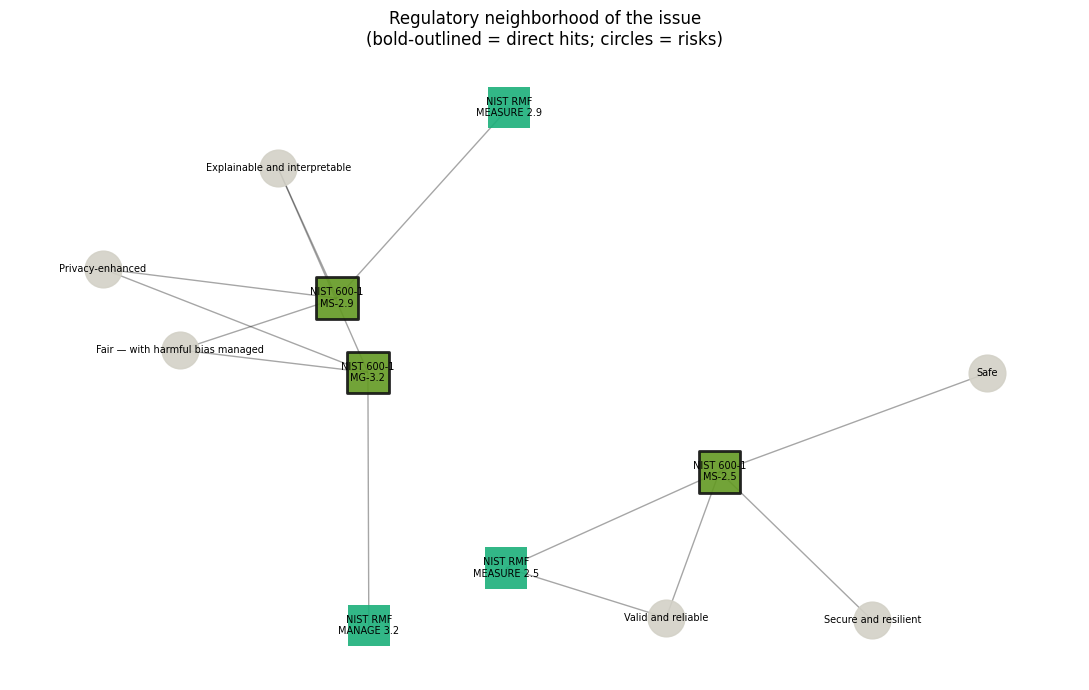

In [13]:
_ = reg.visualize(scenario, top_k=3)   # needs matplotlib

## 8. Coverage across scenarios

Run the whole categorized scenario set at once to see how well the corpus covers different governance themes \u2014 which frameworks and risk categories each scenario exercises. A quick way to spot gaps (a theme where too few frameworks or risks light up may need more crosswalks or provisions).

In [ ]:
demo.coverage_report(reg)

## What's next

- **Sharper retrieval** — set `RETRIEVER = 'embedding'` above for embedding-quality context.
- **Evidence paths** — return the full trail (issue → provision → crosswalk → provision) via GKN's path explainer.
- **Measure the claim** — benchmark the graph-grounded answer against a flat-RAG baseline.
- **Interface** — a "submit an issue" web UI.

**Extend Regulus:** add crosswalk rows or frameworks under `data/`, or swap the seed crosswalks for authoritative mappings.